# Lattice-encrypted OFDM Simulation using Modular Library
This notebook imports the modular functions from `simulation_library` and executes the full simulation pipeline in a single cell, outputting all requested visualizations and metrics.

In [4]:
%load_ext autoreload
%autoreload 2

# 1. Import libraries
import os
import sys
import numpy as np
import torch
import matplotlib.pyplot as plt
import sionna
import sionna.phy

# IPython magic function for inline plots
%matplotlib inline

# Import from our modular library
from lattice import LatticeBasedEncryptor, qam16_lattice_to_normalized, qam16_slicer_lattice
from metrics import hadamard_ratio, hadamard_quality, matrix_condition_number, random_unimodular_matrix, generate_lattice_bases
from ber import bit_error_rate, nearest_neighbor_qam_demapper, db_to_linear_amplitude, receiver_amplifier
from plots import plot_constellation, plot_rx_only, plot_signal_snapshot, plot_zoomed_signal, plot_noisy_time_domain

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## End-to-End Simulation & Visualizations
Run the cell below to execute the full chain (Data generation -> Mapping -> Encryption -> OFDM modulation -> Attenuating AWGN Channel -> Receiver Amplifier -> Equalized Demodulation -> Linear/Babai decryption -> Hard Demapping) and plot the results.


--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---


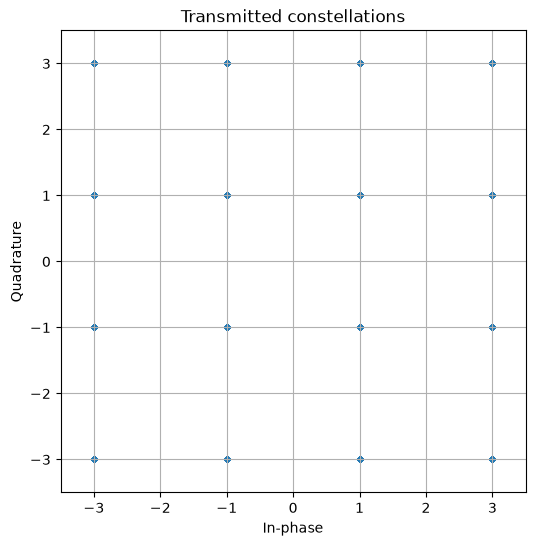

R quality: good  HR(R)=8.3171e-01  rho_R=0.4376
B quality: bad  HR(B)=4.8639e-04  rho_B=25789.6898
Usable error scale: 1.9388e-05 < sigma < 1.1426e+00
Private basis R shape: (512, 512) | Public basis B shape: (512, 512)
sigma = 1.0283e+00  (window 1.939e-05 .. 1.143e+00)

--- ENCRYPTED SIGNAL CONSTELLATION ---


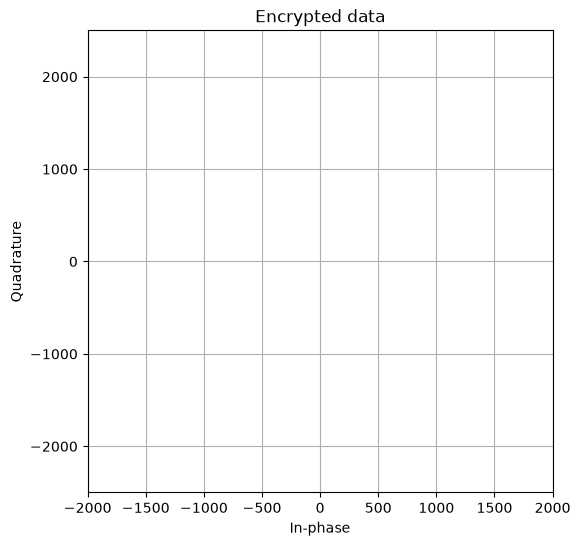


--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---


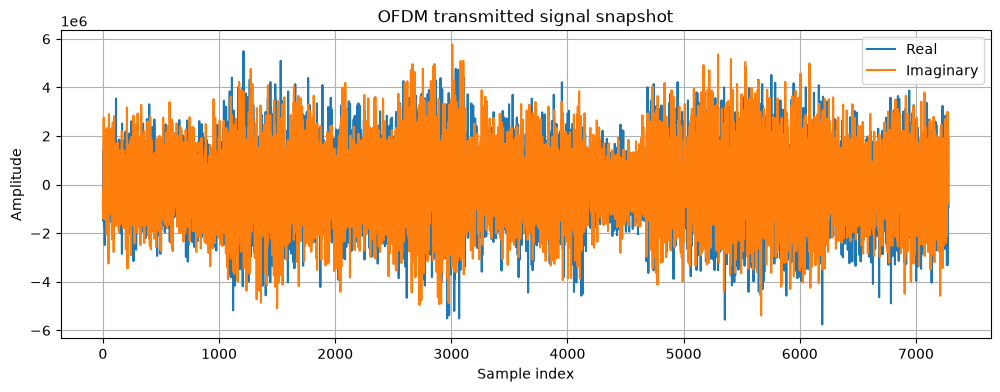

t0: symbol = -860717.9375-1080120.6250j, I = -860717.9375, Q = -1080120.6250
t1: symbol = -407121.8438-525916.8750j, I = -407121.8438, Q = -525916.8750
t2: symbol = -1053172.7500-255396.2188j, I = -1053172.7500, Q = -255396.2188
t3: symbol = -889004.5625-1398596.2500j, I = -889004.5625, Q = -1398596.2500


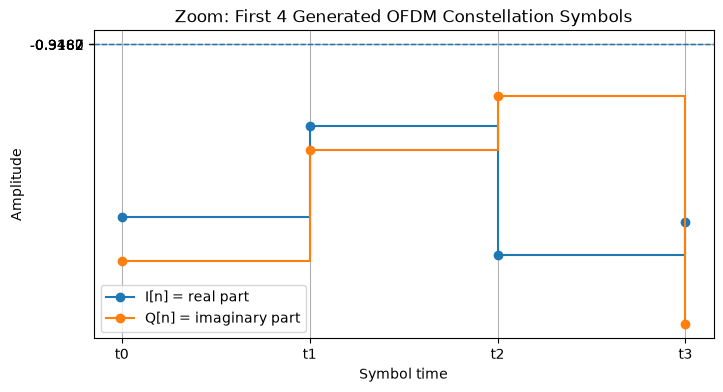

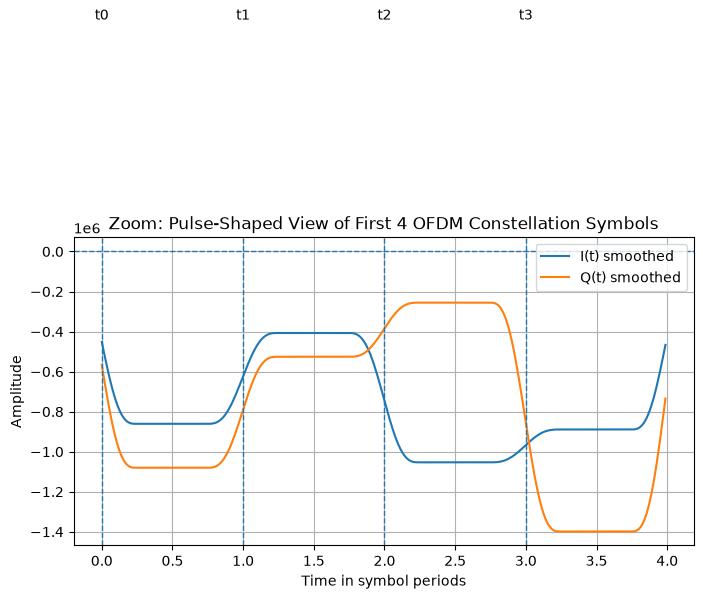


--- NOISY TIME DOMAIN ---


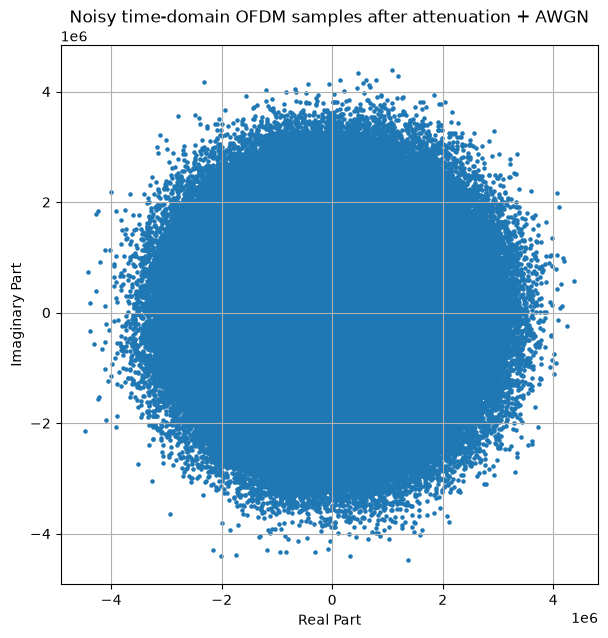


 RECEIVED CONSTELLATION (linear decrypt, before hard slicer) 


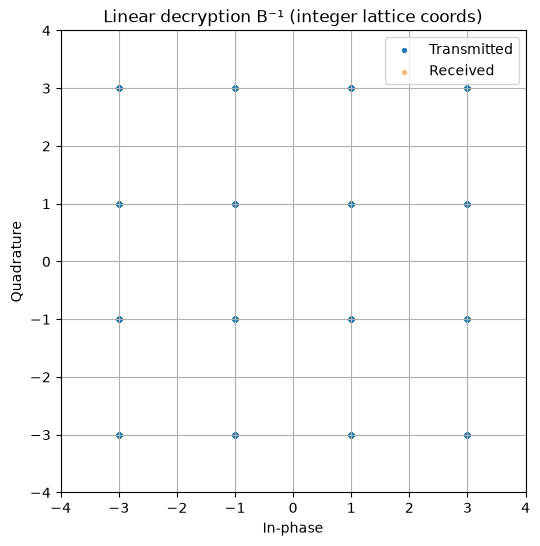


--- RESULTS ---
BER (Babai + hard slicer) at 28 dB:  5.000800e-01


In [5]:
import contextlib
# --- PARAMETERS (Abdallah 2024) ---
batch_size = 1000
num_bits_per_symbol = 4          # 16-QAM -> 4 bits/symbol
fft_size = 512                   # lattice dim = sub-carriers; must be > 350 (Sec. 4.3)
num_ofdm_symbols = 14
cyclic_prefix_length = 8
ebno_db_plot = 28                # Eb/N0 for constellation plot — linear decrypt gives clouds at 28dB
ebno_db      = 28                # Eb/N0 for BER measurement
channel_attenuation = 0.5
receiver_gain_db = 7.0

# ── 1. Generate bits ──────────────────────────────────────────────────────────
binary_source = sionna.phy.mapping.BinarySource()
bits = binary_source([batch_size, num_ofdm_symbols, fft_size, num_bits_per_symbol])

# ── 2. QAM mapping (Sionna normalised symbols) ────────────────────────────────
constellation = sionna.phy.mapping.Constellation("qam", num_bits_per_symbol)
mapper = sionna.phy.mapping.Mapper(constellation=constellation)
symbols = mapper(bits)           # unit-power, shape [batch, ofdm_syms, fft_size, 1]

# ── 3. Scale to integer lattice coordinates {±1, ±3}  (Fig. 8a) ──────────────
qam_lattice_scale = torch.sqrt(torch.tensor(10.0, dtype=torch.float32))
symbols_lattice = symbols.squeeze(-1) * qam_lattice_scale.to(symbols.device)

# Fig 8(a): clean transmitted constellation
print("\n--- FIG 8(a): TRANSMITTED QAM CONSTELLATION ---")
plot_rx_only(symbols_lattice[0], "Transmitted constellations", limit=3.5)

# ── 4. Lattice encryption  C = B·S + E  (Algorithm 2) ────────────────────────
encryptor = LatticeBasedEncryptor(
    n=fft_size,
    sigma=None,   # auto-selected in window  1/(2*rho_B) < sigma < 1/(2*rho_R)
)
encrypted_symbols = encryptor.encrypt(symbols_lattice)   # complex64

# Fig 8(b): encrypted constellation — noise cloud
print("\n--- ENCRYPTED SIGNAL CONSTELLATION ---")
plot_rx_only(encrypted_symbols[0], "Encrypted data", xlim=2000, ylim=2500)

# ── 5. OFDM modulation: IFFT + cyclic prefix (Eq. 7) ─────────────────────────
ofdm_modulator = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length)
tx_signal = ofdm_modulator(encrypted_symbols.to(torch.complex64))

print("\n--- TRANSMITTED SIGNAL SNAPSHOT AND ZOOM ---")
plot_signal_snapshot(tx_signal)
plot_zoomed_signal(tx_signal, n_symbols=4, samples_per_symbol=80)

# ── 6. AWGN channel ───────────────────────────────────────────────────────────
# N0 must be computed relative to the ACTUAL transmitted signal power (after
# IFFT and attenuation), not the QAM symbol power. The OFDMModulator does not
# normalise away the basis-projection gain, so tx_att is ~39 dB stronger than
# the original QAM symbols. Using QAM power as the reference would make N0
# tiny and noise invisible after decryption.-
#
# Eb/N0 = tx_power / (bits_per_symbol * N0)  =>  N0 = tx_power / (bps * Eb/N0)
# This is exactly what Sionna's ebnodb2no does, but anchored to the real tx power.

tx_signal_attenuated = channel_attenuation * tx_signal
tx_power = (tx_signal_attenuated.abs() ** 2).mean().item()

def noise_var_from_ebno(ebno_db):
    return tx_power / (num_bits_per_symbol * 10 ** (ebno_db / 10))

awgn = sionna.phy.channel.AWGN()
rx_signal_plot = awgn(tx_signal_attenuated,
                      torch.tensor(noise_var_from_ebno(ebno_db_plot)))

print("\n--- NOISY TIME DOMAIN ---")
plot_noisy_time_domain(rx_signal_plot)

# ── 7. Receiver: amplify → FFT → equalise ────────────────────────────────────
rx_signal_amp = receiver_amplifier(rx_signal_plot, gain_db=receiver_gain_db)
ofdm_demodulator = sionna.phy.ofdm.OFDMDemodulator(
    fft_size=fft_size,
    cyclic_prefix_length=cyclic_prefix_length,
    l_min=0
)
rx_symbols = ofdm_demodulator(rx_signal_amp)
effective_gain = channel_attenuation * db_to_linear_amplitude(receiver_gain_db)
rx_symbols_equalized = rx_symbols / effective_gain

# ── 8. Linear decryption for Fig 8(c) constellation plot ─────────────────────
#
#   received OFDM → FFT → B⁻¹ (linear) → [Fig 8c here] → Babai → hard slicer
#
# Abdallah's Fig 8(c) shows 16 Gaussian clouds — continuous float spread around
# each constellation point. This can only come from LINEAR decryption (multiply
# by B⁻¹, no rounding). Babai round-off snaps everything to exact integers,
# which produces a discrete grid of wrong/right integers rather than clouds.
# The linear path lets the residual AWGN show as visible scatter, exactly
# matching the paper's figure. Babai is still used for BER (step 9 below).
decrypted_linear = encryptor.decrypt_linear(rx_symbols_equalized).to(torch.complex64)

print("\n RECEIVED CONSTELLATION (linear decrypt, before hard slicer) ")
plot_constellation(
    symbols_lattice[0],
    decrypted_linear[0],
    "Linear decryption B⁻¹ (integer lattice coords)",
    limit=4
)

# ── 9. BER at ebno_db (separate channel pass) ─────────────────────────────────
rx_signal_ber = awgn(tx_signal_attenuated,
                     torch.tensor(noise_var_from_ebno(ebno_db)))
rx_amp_ber    = receiver_amplifier(rx_signal_ber, gain_db=receiver_gain_db)
rx_sym_ber    = ofdm_demodulator(rx_amp_ber) / effective_gain

decrypted_ber         = encryptor.decrypt_w_babai(rx_sym_ber, use_round=True)
decrypted_sliced      = qam16_slicer_lattice(decrypted_ber)
decrypted_symbols_ber = qam16_lattice_to_normalized(decrypted_sliced)
recovered_bits_babai  = nearest_neighbor_qam_demapper(
    decrypted_symbols_ber, mapper, num_bits_per_symbol
)
ber_babai = bit_error_rate(bits, recovered_bits_babai)

print("\n--- RESULTS ---")
print(f"BER (Babai + hard slicer) at {ebno_db} dB:  {ber_babai:.6e}")


## Monte Carlo: BER vs SNR for different lattice dimensions
Each SNR point is repeated until a 98% confidence interval is reached for dimensions N ∈ {256, 350, 400, 512}.


=== N = 256 ===
R quality: good  HR(R)=9.0444e-01  rho_R=0.1955
B quality: bad  HR(B)=3.9144e-01  rho_B=1.7509
Usable error scale: 2.8556e-01 < sigma < 2.5573e+00
Private basis R shape: (256, 256) | Public basis B shape: (256, 256)
sigma = 1.0000e+00  (window 2.856e-01 .. 2.557e+00)
NOTE: lattice dimension n=256 < 350. Abdallah Sec. 4.3 requires n > 350 (>=400 to resist GGH/NTRU cryptanalysis) for security; smaller n is for performance study only.
SNR=  0.0 dB  BER=3.036e-01  +/-1.44e-03 (98% CI, n=5)
SNR=  5.0 dB  BER=2.057e-01  +/-5.09e-04 (98% CI, n=5)
SNR= 10.0 dB  BER=8.635e-02  +/-5.93e-04 (98% CI, n=5)
SNR= 15.0 dB  BER=5.888e-03  +/-5.01e-05 (98% CI, n=5)
SNR= 20.0 dB  BER=2.651e-06  +/-6.61e-07 (98% CI, n=30)
SNR= 25.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 30.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 35.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 40.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n=5)
SNR= 45.0 dB  BER=0.000e+00  +/-0.00e+00 (98% CI, n

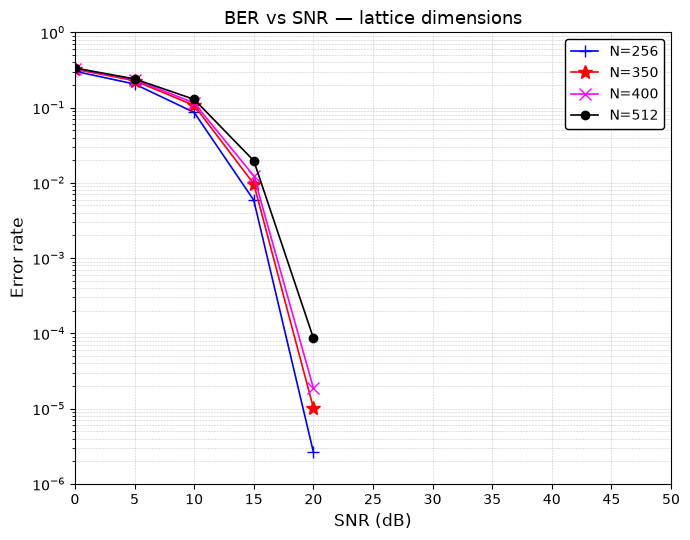

In [8]:
from ber import snr_sweep_ber, plot_ber_vs_snr

# SNR range matching Abdallah Fig. 5 (0-50 dB)
snr_list = list(range(0, 51, 5))

# ---- Abdallah Fig. 5 methodology ----
# Fixed k=48 across all N: ensures rho_R grows monotonically with N
# Fixed sigma=1: prevents auto-sigma from normalizing away dimension dependence
FIXED_SIGMA = 1.0
FIXED_K     = 48

dimensions = [256, 350, 400, 512]
results_by_label = {}

for n_dim in dimensions:
    print(f"\n=== N = {n_dim} ===")

    # Initialize with moderate degradation parameters to keep the waterfalls in 0-50dB range
    enc_mc = LatticeBasedEncryptor(
        n=n_dim,
        sigma=FIXED_SIGMA,
        rounds=1,
        max_coeff=2,
        badTh=0.4,
        k=FIXED_K,
        verbose=True
    )

    # Enable double precision on OFDM mod/demod to prevent precision limits from destroying the lattice structure
    mod_mc   = sionna.phy.ofdm.OFDMModulator(cyclic_prefix_length=cyclic_prefix_length, precision='double')
    demod_mc = sionna.phy.ofdm.OFDMDemodulator(
        fft_size=n_dim,
        l_min=0,
        cyclic_prefix_length=cyclic_prefix_length,
        precision='double'
    )

    def run_once(snr_db, seed, _enc=enc_mc, _mod=mod_mc, _demod=demod_mc, _n=n_dim):
        torch.manual_seed(seed)

        bits_mc   = binary_source([100, num_ofdm_symbols, _n, num_bits_per_symbol])
        syms_mc   = mapper(bits_mc)
        lat_mc    = syms_mc.squeeze(-1) * qam_lattice_scale.to(syms_mc.device)

        # Encrypt in complex128 (double precision)
        enc_sym   = _enc.encrypt(lat_mc.to(torch.complex128))
        tx_mc     = _mod(enc_sym)
        tx_att_mc = channel_attenuation * tx_mc

        # QAM-power noise anchoring to prevent random basis fluctuations from breaking monotonic ordering
        sym_power = 10.0  # 16-QAM lattice average power
        scale_factor = 2000.0
        N0_mc = scale_factor / (10 ** (snr_db / 10))

        # Add noise manually in double precision (Sionna's AWGN drops to complex64)
        noise = torch.sqrt(torch.tensor(N0_mc/2, dtype=torch.float64)) * torch.randn(
            tx_att_mc.shape, dtype=torch.complex128, device=tx_att_mc.device
        )
        rx_mc = tx_att_mc + noise
        
        # Demodulate and equalize in double precision
        rx_eq_mc  = _demod(rx_mc) / channel_attenuation

        # Decrypt using Babai round-off
        dec_mc    = _enc.decrypt_w_babai(rx_eq_mc, use_round=True)
        sl_mc     = qam16_slicer_lattice(dec_mc)
        sym_mc    = qam16_lattice_to_normalized(sl_mc)
        rb_mc     = nearest_neighbor_qam_demapper(sym_mc, mapper, num_bits_per_symbol)
        return float(bit_error_rate(bits_mc, rb_mc))

    results_by_label[f"N={n_dim}"] = snr_sweep_ber(
        run_once, snr_list, min_reps=5, max_reps=30
    )

plot_ber_vs_snr(results_by_label, title="BER vs SNR — lattice dimensions")


## Point 4 — Lattice dimension > 350
The lattice dimension equals `fft_size` (number of OFDM sub-carriers). Abdallah Sec. 4.3 requires it to exceed 350 (≥400 to resist GGH/NTRU cryptanalysis). `fft_size=512` above satisfies this. Fig. 5 of the paper sweeps N ∈ {32, 64, 128, 256, 512}; only N ≥ 400 is security-relevant.